In [1]:
# Zelle 1: Import testen
from data_reconciliation.io.reader import read_excel
from data_reconciliation.preprocessing.filter import IQRFilter, ResidualFilter, CompositeFilter, filter_report
from data_reconciliation.reconciliation.reconcile import reconcile
from data_reconciliation.visualization.plots import plot_timeseries, plot_corrections
from data_reconciliation.visualization.save import save_figure
from data_reconciliation.reconciliation.balance import compute_mass_balance
from pathlib import Path

print("✓ Alle Module geladen")



✓ Alle Module geladen


In [2]:
# Zelle 2: Daten einlesen
ROOT = Path().resolve().parent        # funktioniert in Notebooks aus notebooks/
data = read_excel(ROOT / "data" / "demo-daten_4.xlsx")
X, A, rho = data["X"], data["A"], data["rho"]
stream_ids         = data["stream_ids"]
stream_meta        = data["stream_meta"]   # dict {int: {klarname, nominal, einheit, typ}}
stream_names       = [stream_meta[sid]["klarname"] for sid in stream_ids]
balance_names     = data["balance_names"]
print(f"X: {X.shape}, A: {A.shape}, rho: {rho}")
print(f"Ströme: {stream_names}")
print(f"Bilanzen: {balance_names}")

X: (3000, 6), A: (3, 6), rho: [0.02  0.05  0.005 0.005 0.02  0.1  ]
Ströme: ['Rohbutan', 'Synthesegas', 'Kreisgas', 'Reaktorausgang', 'Valeraldehyd', 'Purge']
Bilanzen: ['Gesamtbilanz', 'Reaktor', 'Trennung/Flash']


{'residuals': array([[  32.8 ,   82.54,  -49.74],
       [  66.46,   48.01,   18.45],
       [  31.98,  -67.13,   99.11],
       ...,
       [  -5.42,  495.76, -501.18],
       [  14.83,  460.15, -445.32],
       [  24.35, -287.81,  312.16]], shape=(3000, 3)), 'residuals_mean': array([  17.76305667,  498.11749667, -480.35444   ]), 'balance_names': None}


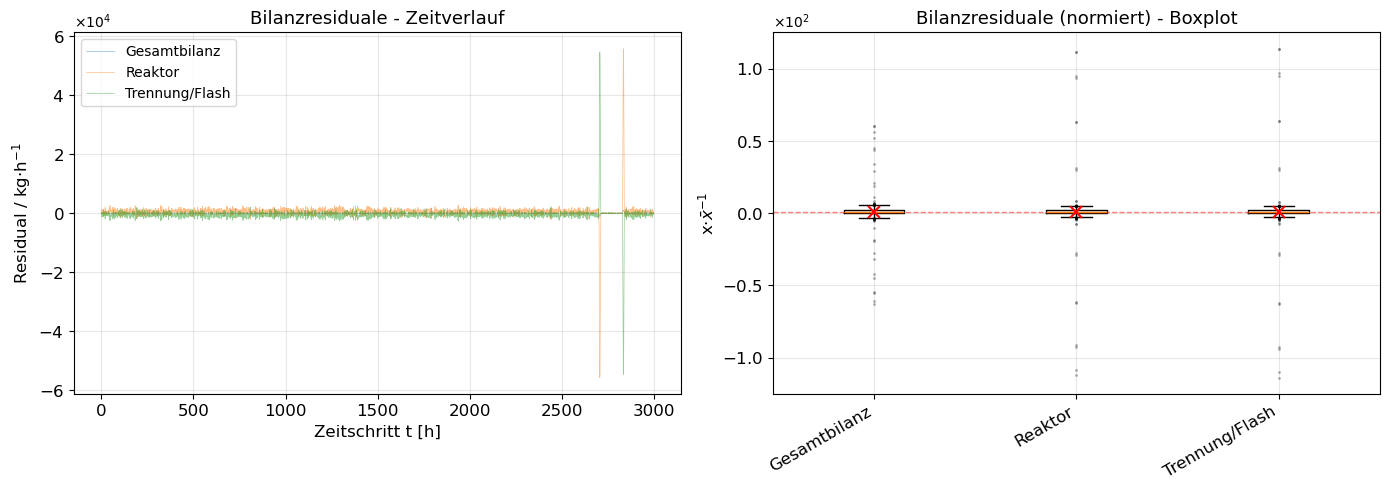

In [3]:
# Massenbilanz ungefiltert
mb_uf = compute_mass_balance(X, A)
print(mb_uf)
all_residuals = mb_uf['residuals']
fig1 = plot_timeseries(X=all_residuals,
                    labels=balance_names,
                    title_left= "Bilanzresiduale - Zeitverlauf",
                    title_right= "Bilanzresiduale (normiert) - Boxplot",
                    xlabel="Zeitschritt t [h]",
                    ylabel_left=r"Residual / kg$\cdot$h$^{-1}$",   # kg·h⁻¹
                    ylabel_right=r"x$\cdot\bar{x}^{-1}$", 
                    normalize=True,
                    hline=1,
                    sci_left=True,
                    sci_right=True)

In [7]:
# Zelle 3: Filtern
# f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
# f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
# detailed = f.fit(X).transform_detailed(X)
# mask = detailed["combined"]
# filter_report(mask, detailed)

# Nur IQR-Filter
f = IQRFilter(k=1.5)
mask = f.fit_transform(X)
filter_report(mask)
X_stat = X[mask]



---------------------------------------------
  Filterung: 3000 Zeitschritte total
  Behalten:  2774  (92.5%)
  Entfernt:  226  (7.5%)
---------------------------------------------


In [8]:
# Zelle 4: Rekonziliation
result = reconcile(X[mask], A, rho)
print(f"Mittlerer SS_res: {result['SS_res'].mean():.6f}")



Mittlerer SS_res: 596.734447


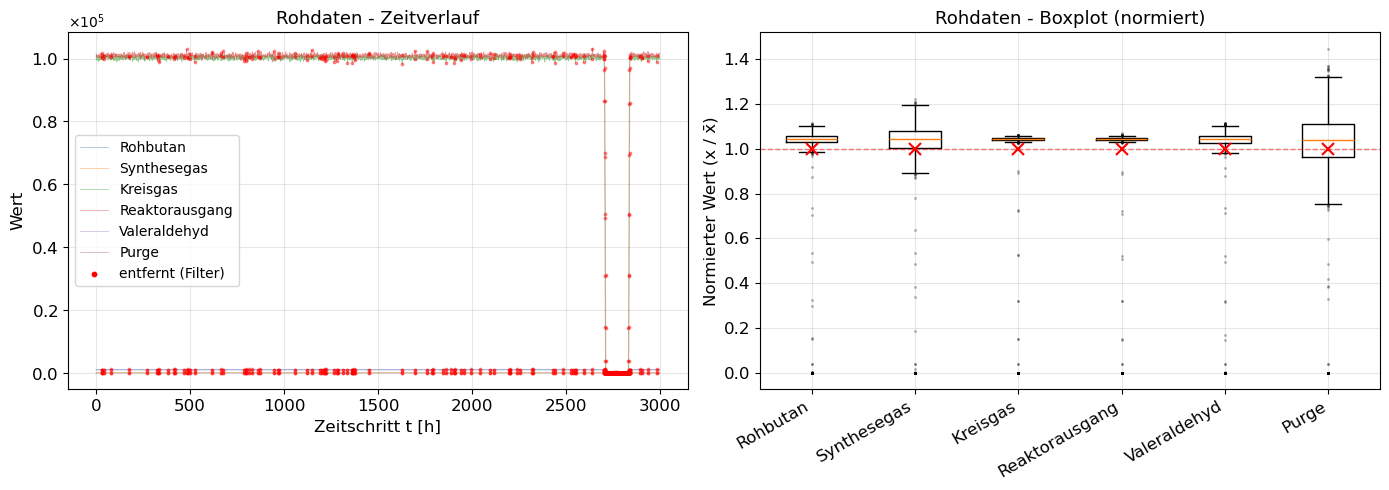

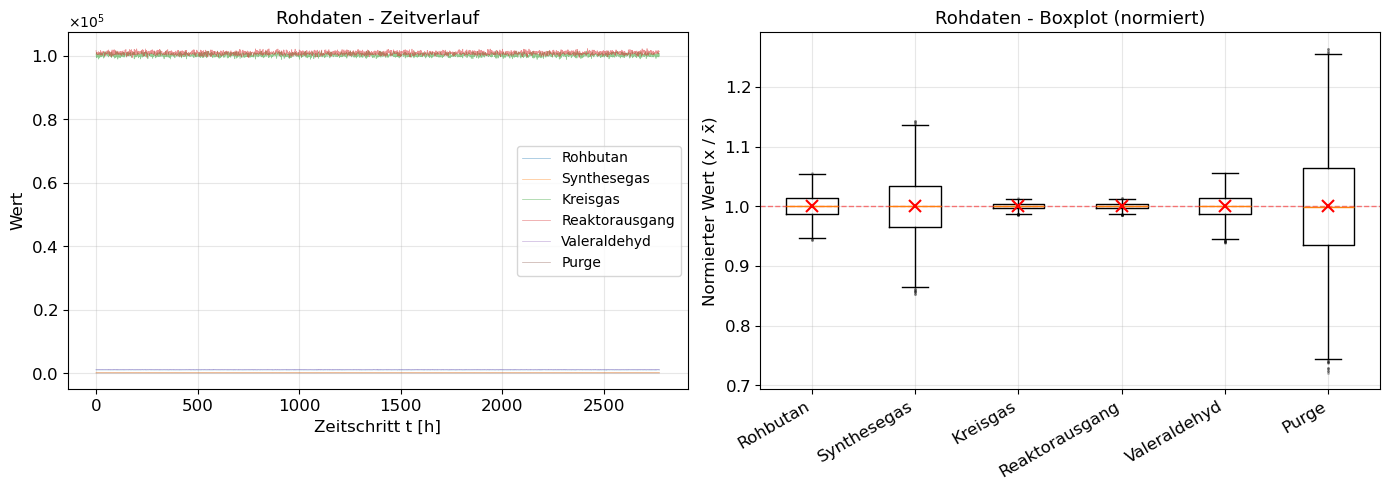

In [9]:
# Zelle 5: Plot
%matplotlib inline
fig2 = plot_timeseries(X, mask=mask, labels=stream_names, normalize=True, sci_left=True, title_left="Rohdaten - Zeitverlauf", title_right="Rohdaten - Boxplot (normiert)")
fig3 = plot_timeseries(X[mask], mask=None, labels=stream_names, normalize=True, sci_left=True, sci_right=True, title_left="Rohdaten - Zeitverlauf", title_right="Rohdaten - Boxplot (normiert)")
#fig4 = plot_corrections(X_stat, result["X_rec"], ids=stream_ids, labels=stream_labels)

In [6]:
save_figure(fig1)
save_figure(fig2)

  Gespeichert: C:\Users\Admin\Nextcloud-RP\997_Python-Projekte\data-reconciliation\notebooks\docs\plots\2026-03-10_10-55_rohdaten_zeitverlauf.png  (156 KB)
  Gespeichert: C:\Users\Admin\Nextcloud-RP\997_Python-Projekte\data-reconciliation\notebooks\docs\plots\2026-03-10_10-55_rohdaten_gefiltert_-_zeitverlauf.png  (134 KB)


'C:\\Users\\Admin\\Nextcloud-RP\\997_Python-Projekte\\data-reconciliation\\notebooks\\docs\\plots\\2026-03-10_10-55_rohdaten_gefiltert_-_zeitverlauf.png'